# SIT307/SIT720 Task 11.1HD: Machine Learning Mini Research

**Student:** Tien Phat Thai (225213834)

**Selected paper:** M. Bhagat, A. Sharma and P. Agarwal, "An efficient stacking-based ensemble technique for early heart attack prediction," *Multimedia Tools and Applications*, vol. 84, pp. 36351-36375, 2025, doi: 10.1007/s11042-024-19293-7.

This notebook contains all code for the technical report:

* **Part 1: Reproduction.** Data audit, recovery of the paper's train/test split, reproduction of the six base classifiers and the 5-fold stacking ensemble, robustness over 100 random splits, an audit of the metrics reported in the paper, and a leakage analysis.
* **Part 2: Proposed solution (LA-DPS).** Leakage-Aware, Diversity-Pruned Stacking, evaluated with patient-level (group-aware) repeated cross-validation on the original 1025-row file, with an ablation study and paired statistical tests.

Every table and figure in the report is produced by this notebook and saved to `results/` and `figures/`.
Expected runtime: about 20 minutes on Google Colab (2 CPUs). Expensive loops are checkpointed in `results/cache/`, so a disconnected session resumes where it stopped; delete that folder to recompute everything.

In [13]:
# Environment. On Google Colab the two libraries that affect the numerical results are pinned
# to the versions used for the report. Run this cell first, before any other import.
import sys, subprocess
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                    'scikit-learn==1.8.0', 'xgboost==3.4.1'], check=True)

In [14]:
import os, time, json, platform, urllib.request, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import scipy
from scipy import stats
import sklearn, xgboost
from joblib import Parallel, delayed
from sklearn.base import BaseEstimator, ClassifierMixin, TransformerMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (brier_score_loss, confusion_matrix, log_loss,
                             roc_auc_score, roc_curve)
from sklearn.model_selection import (GridSearchCV, StratifiedGroupKFold, StratifiedKFold,
                                     cross_val_predict, train_test_split)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 200, 'font.size': 10,
                     'axes.unicode_minus': False, 'axes.spines.top': False,
                     'axes.spines.right': False})

SEED = 42                 # model seed used throughout
N_JOBS = -1               # parallel workers (results do not depend on this value)
N_RANDOM_SPLITS = 100     # Part 1 robustness sweep of the paper's protocol
N_FOLDS, N_REPEATS = 5, 10  # patient-level repeated stratified CV (50 outer folds)
SEED_SEARCH = 20000       # seeds scanned when recovering the paper's split
DATA_DIR, RES_DIR, FIG_DIR = Path('data'), Path('results'), Path('figures')
CACHE_DIR = RES_DIR / 'cache'           # checkpoints so an interrupted run can resume
for d in (DATA_DIR, RES_DIR, FIG_DIR, CACHE_DIR):
    d.mkdir(exist_ok=True)

def cached_call(tag, fn, *args):
    """Run fn(*args) once and store the result in results/cache/, so a disconnected
    Colab session can resume. Delete results/cache/ to recompute everything from scratch."""
    import pickle
    path = CACHE_DIR / f'v1_{tag}.pkl'
    if path.exists():
        with open(path, 'rb') as fh:
            return pickle.load(fh)
    out = fn(*args)
    with open(path, 'wb') as fh:
        pickle.dump(out, fh)
    return out

print('Python', platform.python_version(), '| numpy', np.__version__, '| pandas', pd.__version__,
      '| scikit-learn', sklearn.__version__, '| xgboost', xgboost.__version__,
      '| scipy', scipy.__version__, '| matplotlib', matplotlib.__version__)
print('CPUs available:', os.cpu_count())
T_START = time.time()

Python 3.13.15 | numpy 2.1.3 | pandas 2.2.3 | scikit-learn 1.8.0 | xgboost 3.4.1 | scipy 1.16.3 | matplotlib 3.10.0
CPUs available: 2


## 1. Data

The paper uses the Kaggle "Heart Disease Dataset" (D. Lapp): 1025 records, 13 predictors and a binary target (1 = disease).
The file is included in the repository at `data/heart.csv`. If it is missing (for example when the notebook is opened directly in Colab), it is downloaded from the project repository. A content hash confirms that the exact file used for the report is loaded.

In [15]:
FEATURES = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
            'exang', 'oldpeak', 'slope', 'ca', 'thal']
TARGET = 'target'
DATA_PATH = DATA_DIR / 'heart.csv'
DATA_URL = 'https://raw.githubusercontent.com/phatthai/sit307-hd-stacking-heart/main/data/heart.csv'
EXPECTED_HASH = 8726740167315441832

if not DATA_PATH.exists():
    try:
        urllib.request.urlretrieve(DATA_URL, DATA_PATH)
        print('Downloaded', DATA_URL)
    except Exception as e:
        raise FileNotFoundError('heart.csv not found. Download it from '
                                'https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset '
                                f'and place it at {DATA_PATH}') from e

df = pd.read_csv(DATA_PATH)
assert list(df.columns) == FEATURES + [TARGET], 'unexpected column layout'
content_hash = int(pd.util.hash_pandas_object(df, index=False).sum())
print('Shape:', df.shape, '| missing values (NaN):', int(df.isna().sum().sum()))
print('Content hash:', content_hash, '(matches report file)' if content_hash == EXPECTED_HASH
      else 'WARNING: differs from the file used in the report')
df.head()

Shape: (1025, 14) | missing values (NaN): 0
Content hash: 8726740167315441832 (matches report file)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


### 1.1 Data audit: duplicates, invalid codes and provenance

Exact duplicates (all 14 attributes identical) are counted, each unique record receives a group id, and codes outside the documented UCI ranges (`ca` = 4, `thal` = 0) are flagged. These invalid codes are how the Kaggle file represents missing values.

                               Quantity     Value
                                Records      1025
                Exact duplicate records       723
              Unique records (patients)       302
Feature vectors with conflicting labels         0
             Target 1 / 0 (all records) 526 / 499
          Target 1 / 0 (unique records) 164 / 138
                  ca = 4 (all / unique)    18 / 4
                thal = 0 (all / unique)     7 / 2
            Minimum cholesterol (mg/dl)       126

Copies per unique record: {3: 187, 4: 114, 8: 1}


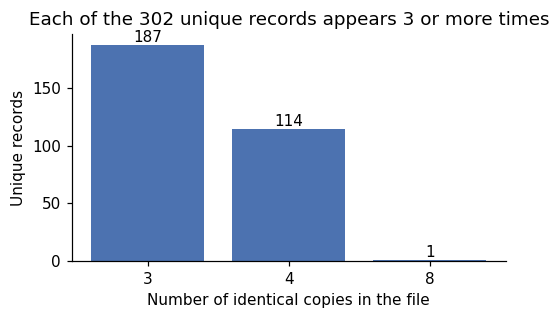

In [16]:
X_raw, y_all = df[FEATURES], df[TARGET].values
key = df[FEATURES + [TARGET]].astype(str).agg('|'.join, axis=1)
groups = pd.factorize(key)[0]                       # patient (unique record) id
uniq = df.drop_duplicates().reset_index(drop=True)
copies = pd.Series(groups).value_counts().value_counts().sort_index()
conflicts = int((df.groupby(FEATURES)[TARGET].nunique() > 1).sum())

audit = pd.DataFrame({
    'Quantity': ['Records', 'Exact duplicate records', 'Unique records (patients)',
                 'Feature vectors with conflicting labels', 'Target 1 / 0 (all records)',
                 'Target 1 / 0 (unique records)', 'ca = 4 (all / unique)', 'thal = 0 (all / unique)',
                 'Minimum cholesterol (mg/dl)'],
    'Value': [len(df), int(df.duplicated().sum()), len(uniq), conflicts,
              f"{(y_all == 1).sum()} / {(y_all == 0).sum()}",
              f"{(uniq[TARGET] == 1).sum()} / {(uniq[TARGET] == 0).sum()}",
              f"{(df.ca == 4).sum()} / {(uniq.ca == 4).sum()}",
              f"{(df.thal == 0).sum()} / {(uniq.thal == 0).sum()}", int(df.chol.min())]})
audit.to_csv(RES_DIR / 'data_audit.csv', index=False)
print(audit.to_string(index=False))
print('\nCopies per unique record:', copies.to_dict())

fig, ax = plt.subplots(figsize=(4.8, 3))
ax.bar([str(i) for i in copies.index], copies.values, color='#4C72B0')
for i, v in enumerate(copies.values):
    ax.text(i, v + 3, str(v), ha='center')
ax.set_xlabel('Number of identical copies in the file'); ax.set_ylabel('Unique records')
ax.set_title('Each of the 302 unique records appears 3 or more times')
plt.tight_layout(); plt.savefig(FIG_DIR / 'fig_duplicates.png', bbox_inches='tight'); plt.show()

## 2. Shared components: preprocessing, models and metrics

**Paper preprocessing (Section 3.1).** The paper fills missing values by linear regression imputation and standardises the attributes. The Kaggle file contains no NaN, so the invalid codes `ca` = 4 and `thal` = 0 are treated as the missing values: they are predicted by a linear regression on the other 11 attributes and rounded to the nearest valid code. All 13 attributes are then standardised.

**Paper models.** The paper does not report hyperparameters, a random seed or the meta-classifier, so library defaults are used (the decision tree uses entropy, as in the paper's Eq. 2) and stacking uses 5-fold out-of-fold probabilities with a logistic regression meta-classifier (scikit-learn's standard design).

In [17]:
MODEL_ORDER = ['LR', 'DT', 'RF', 'XGB', 'NB', 'KNN']
ALL_MODELS = MODEL_ORDER + ['Stacking']

class RegressionImputer(BaseEstimator, TransformerMixin):
    """Paper-style imputation: invalid codes (ca = 4, thal = 0) are predicted by a
    linear regression on the remaining attributes, rounded and clipped to valid codes."""
    TARGETS = {'ca': (4, 0, 3), 'thal': (0, 1, 3)}      # invalid code, valid min, valid max

    def fit(self, X, y=None):
        X = pd.DataFrame(X, columns=FEATURES).astype(float)
        self.others_ = [c for c in FEATURES if c not in self.TARGETS]
        self.models_ = {c: LinearRegression().fit(X.loc[X[c] != bad, self.others_], X.loc[X[c] != bad, c])
                        for c, (bad, _, _) in self.TARGETS.items()}
        return self

    def transform(self, X):
        X = pd.DataFrame(X, columns=FEATURES).astype(float).copy()
        for c, (bad, lo, hi) in self.TARGETS.items():
            m = X[c] == bad
            if m.any():
                X.loc[m, c] = np.clip(np.round(self.models_[c].predict(X.loc[m, self.others_])), lo, hi)
        return X.values

def paper_preprocessor():
    return Pipeline([('impute', RegressionImputer()), ('scale', StandardScaler())])

def paper_base_models(seed=SEED):
    return {'LR': LogisticRegression(max_iter=1000),
            'DT': DecisionTreeClassifier(criterion='entropy', random_state=seed),
            'RF': RandomForestClassifier(random_state=seed, n_jobs=1),
            'XGB': XGBClassifier(random_state=seed, eval_metric='logloss', n_jobs=1),
            'NB': GaussianNB(),
            'KNN': KNeighborsClassifier()}

def paper_stacking(seed=SEED):
    return StackingClassifier(estimators=list(paper_base_models(seed).items()),
                              final_estimator=LogisticRegression(max_iter=1000),
                              cv=StratifiedKFold(5, shuffle=True, random_state=seed),
                              stack_method='predict_proba')

def paper_models(seed=SEED):
    return {**paper_base_models(seed), 'Stacking': paper_stacking(seed)}

class DedupFit(BaseEstimator, ClassifierMixin):
    """Fits the wrapped estimator on unique training records only (exact duplicates removed)."""
    def __init__(self, estimator=None):
        self.estimator = estimator
    def fit(self, X, y):
        d = pd.DataFrame(X, columns=FEATURES).assign(_y=np.asarray(y)).drop_duplicates()
        self.estimator_ = clone(self.estimator).fit(d[FEATURES], d['_y'].values)
        self.classes_ = self.estimator_.classes_
        return self
    def predict_proba(self, X):
        return self.estimator_.predict_proba(pd.DataFrame(X, columns=FEATURES))
    def predict(self, X):
        return self.estimator_.predict(pd.DataFrame(X, columns=FEATURES))

def metrics_from_cm(tn, fp, fn, tp):
    den = np.sqrt(float((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn)))
    return {'Accuracy': (tp + tn) / (tp + tn + fp + fn),
            'Precision': tp / (tp + fp) if tp + fp else 0.0,
            'Recall': tp / (tp + fn) if tp + fn else 0.0,
            'F1': 2 * tp / (2 * tp + fp + fn) if tp else 0.0,
            'Specificity': tn / (tn + fp) if tn + fp else 0.0,
            'MCC': (tp * tn - fp * fn) / den if den else 0.0}

def evaluate(y_true, y_pred, y_prob):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    m = metrics_from_cm(tn, fp, fn, tp)
    m['AUC'] = roc_auc_score(y_true, y_prob)
    m['Brier'] = brier_score_loss(y_true, y_prob)
    return m

METRICS = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC', 'Specificity', 'MCC', 'Brier']

# Values reported in the paper: Table 11 (eight columns, in the paper's order) and the
# confusion matrices of Figs. 3 and 5, stored as [TN, FP, FN, TP].
PAPER_T11 = pd.DataFrame(
    [[0.8439, 0.8620, 0.9090, 0.8196, 0.8439, 0.8620, 0.8196, 0.9204],
     [0.9268, 0.9289, 0.8909, 0.9702, 0.9268, 0.9289, 0.9702, 0.9702],
     [0.9268, 0.9333, 0.9545, 0.9130, 0.9268, 0.9333, 0.9130, 0.9734],
     [0.9073, 0.9132, 0.9090, 0.9174, 0.9073, 0.9132, 0.9174, 0.9830],
     [0.8439, 0.8608, 0.9000, 0.8250, 0.8439, 0.8608, 0.8250, 0.9185],
     [0.8585, 0.8687, 0.8727, 0.8648, 0.8585, 0.8687, 0.8648, 0.9304],
     [0.9853, 0.9861, 0.9727, 1.0000, 0.9853, 0.9861, 1.0000, 0.9880]],
    index=ALL_MODELS,
    columns=['Accuracy', 'F1', 'Recall', 'Precision', 'Sensitivity', 'Specificity', 'MCC', 'AUC'])
PAPER_CM = {'LR': [73, 22, 10, 100], 'DT': [92, 3, 12, 98], 'RF': [85, 10, 5, 105],
            'XGB': [86, 9, 10, 100], 'NB': [74, 21, 11, 99], 'KNN': [80, 15, 14, 96],
            'Stacking': [95, 0, 3, 107]}
print('Components defined.')

Components defined.


## 3. Part 1: Reproduction of the paper

### 3.1 Recovering the paper's train/test split

Following the paper, preprocessing is fitted on the full dataset and the data are then split 80/20 at record level. The paper's confusion matrices show a test set of 205 records with 95 negatives and 110 positives, which is not a stratified split. The paper gives no seed, so seeds 0 to 19,999 of `train_test_split` are scanned for splits with this composition. Gaussian Naive Bayes and logistic regression are deterministic, so their confusion matrices act as fingerprints of the split.

In [18]:
prep_full = paper_preprocessor().fit(X_raw)        # paper: preprocess first, then split
X_paper = prep_full.transform(X_raw)
idx_all = np.arange(len(df))

def split(seed):
    return train_test_split(idx_all, test_size=0.2, random_state=seed)

def cm_on_split(model, seed):
    tr, te = split(seed)
    m = clone(model).fit(X_paper[tr], y_all[tr])
    return confusion_matrix(y_all[te], m.predict(X_paper[te])).ravel().tolist()

t0 = time.time()
comp_match = [s for s in range(SEED_SEARCH)
              if ((y_all[split(s)[1]] == 0).sum(), (y_all[split(s)[1]] == 1).sum()) == (95, 110)]
nb_match = [s for s in comp_match if cm_on_split(GaussianNB(), s) == PAPER_CM['NB']]
lr_match = [s for s in nb_match if cm_on_split(LogisticRegression(max_iter=1000), s) == PAPER_CM['LR']]
knn_match = [s for s in lr_match if cm_on_split(KNeighborsClassifier(), s) == PAPER_CM['KNN']]
SPLIT_SEED = lr_match[0] if lr_match else (nb_match[0] if nb_match else 42)

recovery = pd.DataFrame({'Criterion': ['Seeds scanned', 'Test set = 95 negatives / 110 positives',
                                       '+ NB confusion matrix identical to paper',
                                       '+ LR confusion matrix identical to paper',
                                       '+ KNN (k = 5) confusion matrix identical to paper'],
                         'Seeds': [SEED_SEARCH, len(comp_match), len(nb_match), len(lr_match), len(knn_match)]})
recovery.to_csv(RES_DIR / 'split_recovery.csv', index=False)
print(recovery.to_string(index=False))
print(f'NB matches: {nb_match} | LR matches: {lr_match}')
print(f'Selected split seed: {SPLIT_SEED}  ({time.time() - t0:.1f}s)')

                                        Criterion  Seeds
                                    Seeds scanned  20000
          Test set = 95 negatives / 110 positives    986
         + NB confusion matrix identical to paper      6
         + LR confusion matrix identical to paper      1
+ KNN (k = 5) confusion matrix identical to paper      0
NB matches: [1178, 2258, 3269, 6600, 12496, 15409] | LR matches: [2258]
Selected split seed: 2258  (60.4s)


### 3.2 Reproduced results on the recovered split

All six base classifiers and the stacking ensemble are trained on the recovered training set and evaluated on the 205 test records with the paper's metrics (Accuracy, Precision, Recall, F1, AUC), plus Specificity and MCC.

In [19]:
tr_p, te_p = split(SPLIT_SEED)
seen_p = np.isin(groups[te_p], groups[tr_p])
repro_rows, roc_data = [], {}
for name, model in paper_models().items():
    m = clone(model).fit(X_paper[tr_p], y_all[tr_p])
    prob = m.predict_proba(X_paper[te_p])[:, 1]
    pred = m.predict(X_paper[te_p])
    cm = confusion_matrix(y_all[te_p], pred).ravel().tolist()
    repro_rows.append({'Model': name, **evaluate(y_all[te_p], pred, prob), 'CM [TN,FP,FN,TP]': cm,
                       'Paper CM': PAPER_CM[name]})
    roc_data[name] = roc_curve(y_all[te_p], prob)[:2] + (roc_auc_score(y_all[te_p], prob),)
repro = pd.DataFrame(repro_rows).set_index('Model')

cmp = pd.DataFrame(index=ALL_MODELS)
for c in ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']:
    cmp[f'{c} (paper)'] = PAPER_T11[c]
    cmp[f'{c} (ours)'] = repro[c].round(4)
cmp['Accuracy diff'] = (repro['Accuracy'] - PAPER_T11['Accuracy']).round(4)
repro.to_csv(RES_DIR / 'reproduction_recovered_split.csv')
cmp.to_csv(RES_DIR / 'reproduction_vs_paper.csv')
print(f'Split seed {SPLIT_SEED}: {seen_p.sum()} of {len(te_p)} test records ({seen_p.mean():.1%}) '
      'have an exact duplicate in the training set.\n')
print(repro[['Accuracy', 'Precision', 'Recall', 'F1', 'AUC', 'Specificity', 'MCC']].round(4).to_string())
print()
print(repro[['CM [TN,FP,FN,TP]', 'Paper CM']].to_string())
cmp

Split seed 2258: 202 of 205 test records (98.5%) have an exact duplicate in the training set.

          Accuracy  Precision  Recall      F1     AUC  Specificity     MCC
Model                                                                     
LR          0.8439     0.8197  0.9091  0.8621  0.9425       0.7684  0.6883
DT          1.0000     1.0000  1.0000  1.0000  1.0000       1.0000  1.0000
RF          1.0000     1.0000  1.0000  1.0000  1.0000       1.0000  1.0000
XGB         1.0000     1.0000  1.0000  1.0000  1.0000       1.0000  1.0000
NB          0.8439     0.8250  0.9000  0.8609  0.9181       0.7789  0.6872
KNN         0.7902     0.7724  0.8636  0.8155  0.9375       0.7053  0.5791
Stacking    1.0000     1.0000  1.0000  1.0000  1.0000       1.0000  1.0000

           CM [TN,FP,FN,TP]           Paper CM
Model                                         
LR        [73, 22, 10, 100]  [73, 22, 10, 100]
DT          [95, 0, 0, 110]    [92, 3, 12, 98]
RF          [95, 0, 0, 110]   [85, 10, 5,

,Accuracy (paper),Accuracy (ours),Precision (paper),Precision (ours),Recall (paper),Recall (ours),F1 (paper),F1 (ours),AUC (paper),AUC (ours),Accuracy diff
LR,0.8439,0.8439,0.8196,0.8197,0.9090,0.9091,0.8620,0.8621,0.9204,0.9425,0.0000
DT,0.9268,1.0000,0.9702,1.0000,0.8909,1.0000,0.9289,1.0000,0.9702,1.0000,0.0732
RF,0.9268,1.0000,0.9130,1.0000,0.9545,1.0000,0.9333,1.0000,0.9734,1.0000,0.0732
XGB,0.9073,1.0000,0.9174,1.0000,0.9090,1.0000,0.9132,1.0000,0.9830,1.0000,0.0927
NB,0.8439,0.8439,0.8250,0.8250,0.9000,0.9000,0.8608,0.8609,0.9185,0.9181,0.0000
KNN,0.8585,0.7902,0.8648,0.7724,0.8727,0.8636,0.8687,0.8155,0.9304,0.9375,-0.0683
Stacking,0.9853,1.0000,1.0000,1.0000,0.9727,1.0000,0.9861,1.0000,0.9880,1.0000,0.0147


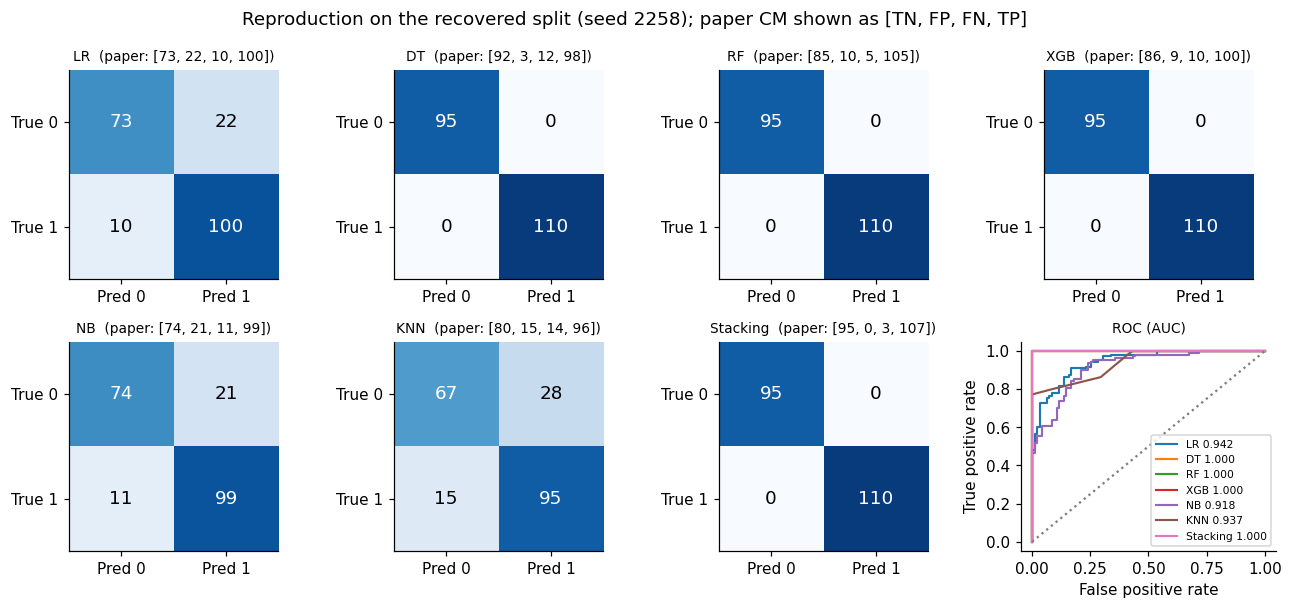

In [20]:
fig, axes = plt.subplots(2, 4, figsize=(12, 5.6))
for ax, name in zip(axes.ravel(), ALL_MODELS):
    tn, fp, fn, tp = repro.loc[name, 'CM [TN,FP,FN,TP]']
    mat = np.array([[tn, fp], [fn, tp]])
    ax.imshow(mat, cmap='Blues', vmin=0, vmax=115)
    for (i, j), v in np.ndenumerate(mat):
        ax.text(j, i, str(v), ha='center', va='center', fontsize=12,
                color='white' if v > 60 else 'black')
    ax.set_xticks([0, 1], ['Pred 0', 'Pred 1']); ax.set_yticks([0, 1], ['True 0', 'True 1'])
    ax.set_title(f"{name}  (paper: {PAPER_CM[name]})", fontsize=9)
ax = axes.ravel()[-1]
for name in ALL_MODELS:
    fpr, tpr, auc = roc_data[name]
    ax.plot(fpr, tpr, lw=1.4, label=f'{name} {auc:.3f}')
ax.plot([0, 1], [0, 1], ls=':', c='grey'); ax.set_title('ROC (AUC)', fontsize=9)
ax.set_xlabel('False positive rate'); ax.set_ylabel('True positive rate'); ax.legend(fontsize=7)
plt.suptitle(f'Reproduction on the recovered split (seed {SPLIT_SEED}); paper CM shown as [TN, FP, FN, TP]')
plt.tight_layout(); plt.savefig(FIG_DIR / 'fig_repro_cm_roc.png', bbox_inches='tight'); plt.show()

### 3.3 Robustness of the paper's protocol over 100 random splits

A single split can be lucky. The paper's protocol (preprocess, then a random 80/20 record-level split) is repeated with seeds 0 to 99. For every split we also record how many test records have an exact duplicate in the training set, and accuracy separately on "seen" and "unseen" test records.

In [21]:
def run_paper_split(s):
    tr, te = split(s)
    seen = np.isin(groups[te], groups[tr])
    rows = []
    for name, model in paper_models().items():
        m = clone(model).fit(X_paper[tr], y_all[tr])
        prob = m.predict_proba(X_paper[te])[:, 1]; pred = m.predict(X_paper[te])
        ok = pred == y_all[te]
        rows.append({'split': s, 'Model': name, 'seen_frac': seen.mean(),
                     'n_unseen': int((~seen).sum()), 'correct_unseen': int(ok[~seen].sum()),
                     'n_seen': int(seen.sum()), 'correct_seen': int(ok[seen].sum()),
                     **evaluate(y_all[te], pred, prob)})
    return rows

t0 = time.time()
sweep = pd.DataFrame([r for rows in Parallel(n_jobs=N_JOBS)(delayed(cached_call)(f'sweep_{s}', run_paper_split, s)
                                                          for s in range(N_RANDOM_SPLITS)) for r in rows])
sweep.to_csv(RES_DIR / 'paper_protocol_100_splits.csv', index=False)
g = sweep.groupby('Model')
sweep_sum = pd.DataFrame({c: g[c].mean().map('{:.4f}'.format) + ' ± ' + g[c].std().map('{:.4f}'.format)
                          for c in ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']}).loc[ALL_MODELS]
sweep_sum['Acc. on seen rows'] = (g['correct_seen'].sum() / g['n_seen'].sum()).loc[ALL_MODELS].round(4)
sweep_sum['Acc. on unseen rows'] = (g['correct_unseen'].sum() / g['n_unseen'].sum()).loc[ALL_MODELS].round(4)
sweep_sum['Paper accuracy'] = PAPER_T11['Accuracy']
sweep_sum.to_csv(RES_DIR / 'paper_protocol_summary.csv')
sf = sweep.drop_duplicates('split')['seen_frac']
print(f'Test records with an exact duplicate in the training set: mean {sf.mean():.1%}, '
      f'min {sf.min():.1%}, max {sf.max():.1%} over {N_RANDOM_SPLITS} splits '
      f'(pooled unseen test records: {int(sweep.drop_duplicates("split")["n_unseen"].sum())})')
print(f'({time.time() - t0:.0f}s)')
sweep_sum

Test records with an exact duplicate in the training set: mean 97.6%, min 91.2%, max 100.0% over 100 splits (pooled unseen test records: 494)
(177s)


,Accuracy,Precision,Recall,F1,AUC,Acc. on seen rows,Acc. on unseen rows,Paper accuracy
Model,,,,,,,,
LR,0.8581 ± 0.0188,0.8322 ± 0.0302,0.9084 ± 0.0245,0.8682 ± 0.0192,0.9294 ± 0.0150,0.8570,0.9028,0.8439
DT,0.9960 ± 0.0083,0.9968 ± 0.0101,0.9956 ± 0.0127,0.9961 ± 0.0081,0.9961 ± 0.0082,1.0000,0.8360,0.9268
RF,0.9971 ± 0.0072,0.9974 ± 0.0083,0.9969 ± 0.0089,0.9971 ± 0.0071,0.9999 ± 0.0004,1.0000,0.8785,0.9268
XGB,0.9968 ± 0.0077,0.9969 ± 0.0105,0.9969 ± 0.0097,0.9968 ± 0.0075,0.9994 ± 0.0026,1.0000,0.8664,0.9073
NB,0.8314 ± 0.0215,0.8133 ± 0.0309,0.8737 ± 0.0302,0.8420 ± 0.0228,0.9138 ± 0.0174,0.8301,0.8846,0.8439
KNN,0.8456 ± 0.0242,0.8459 ± 0.0386,0.8579 ± 0.0347,0.8510 ± 0.0249,0.9540 ± 0.0131,0.8452,0.8583,0.8585
Stacking,0.9972 ± 0.0071,0.9972 ± 0.0094,0.9974 ± 0.0090,0.9973 ± 0.0070,0.9998 ± 0.0013,1.0000,0.8846,0.9853


### 3.4 Audit of the metrics reported in the paper

Every metric in the paper's Table 11 can be recomputed from the paper's own confusion matrices (Fig. 3 and Fig. 5). Sensitivity must equal Recall by definition.

In [22]:
rows = []
for name in ALL_MODELS:
    true = metrics_from_cm(*PAPER_CM[name])
    rep = PAPER_T11.loc[name]
    rows.append({'Model': name,
                 'Accuracy rep/calc': f"{rep['Accuracy']:.4f} / {true['Accuracy']:.4f}",
                 'Recall rep/calc': f"{rep['Recall']:.4f} / {true['Recall']:.4f}",
                 'Sensitivity rep/calc': f"{rep['Sensitivity']:.4f} / {true['Recall']:.4f}",
                 'Specificity rep/calc': f"{rep['Specificity']:.4f} / {true['Specificity']:.4f}",
                 'MCC rep/calc': f"{rep['MCC']:.4f} / {true['MCC']:.4f}"})
audit_t11 = pd.DataFrame(rows).set_index('Model')
audit_t11.to_csv(RES_DIR / 'audit_table11.csv')
copied = {'Sensitivity == Accuracy': bool((PAPER_T11['Sensitivity'] == PAPER_T11['Accuracy']).all()),
          'Specificity == F1': bool((PAPER_T11['Specificity'] == PAPER_T11['F1']).all()),
          'MCC == Precision': bool((PAPER_T11['MCC'] == PAPER_T11['Precision']).all())}
print('Column identities holding for all 7 rows of Table 11:', copied)
audit_t11

Column identities holding for all 7 rows of Table 11: {'Sensitivity == Accuracy': True, 'Specificity == F1': True, 'MCC == Precision': True}


,Accuracy rep/calc,Recall rep/calc,Sensitivity rep/calc,Specificity rep/calc,MCC rep/calc
Model,,,,,
LR,0.8439 / 0.8439,0.9090 / 0.9091,0.8439 / 0.9091,0.8620 / 0.7684,0.8196 / 0.6883
DT,0.9268 / 0.9268,0.8909 / 0.8909,0.9268 / 0.8909,0.9289 / 0.9684,0.9702 / 0.8571
RF,0.9268 / 0.9268,0.9545 / 0.9545,0.9268 / 0.9545,0.9333 / 0.8947,0.9130 / 0.8534
XGB,0.9073 / 0.9073,0.9090 / 0.9091,0.9073 / 0.9091,0.9132 / 0.9053,0.9174 / 0.8138
NB,0.8439 / 0.8439,0.9000 / 0.9000,0.8439 / 0.9000,0.8608 / 0.7789,0.8250 / 0.6872
KNN,0.8585 / 0.8585,0.8727 / 0.8727,0.8585 / 0.8727,0.8687 / 0.8421,0.8648 / 0.7154
Stacking,0.9853 / 0.9854,0.9727 / 0.9727,0.9853 / 0.9727,0.9861 / 1.0000,1.0000 / 0.9711


### 3.5 Hyperparameter sensitivity: why the paper's tree models score lower than ours

The paper's tree-based scores (92.68%) are lower than the 100% obtained with library defaults on the same protocol. Capacity controls the amount of memorisation, so accuracy is traced against tree depth (DT, RF, XGB) and neighbourhood size (KNN) under two protocols: the paper's record-level split (mean of 20 splits) and a patient-level split in which all copies of a patient are kept on the same side (StratifiedGroupKFold, 2 x 5 folds, each test patient counted once).

50 patient-level outer folds; mean unique test patients per fold: 60.4
(66s)


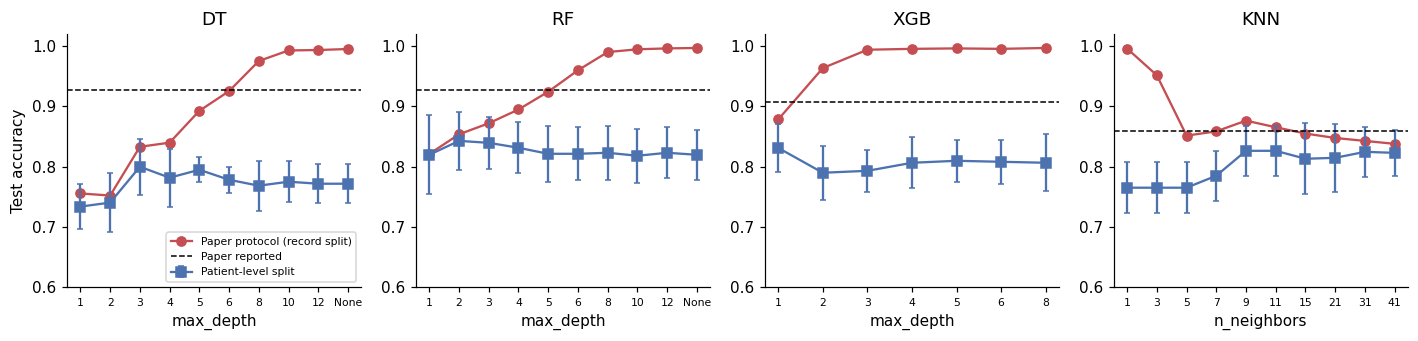

In [23]:
def unique_rows(te):
    _, first = np.unique(groups[te], return_index=True)
    return te[np.sort(first)]

GROUP_FOLDS = []
for r in range(N_REPEATS):
    sgkf = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED + r)
    for k, (tr, te) in enumerate(sgkf.split(X_raw, y_all, groups)):
        assert not set(groups[tr]) & set(groups[te])
        GROUP_FOLDS.append((r, k, tr, unique_rows(te)))
print(f'{len(GROUP_FOLDS)} patient-level outer folds; mean unique test patients per fold: '
      f'{np.mean([len(te) for *_, te in GROUP_FOLDS]):.1f}')

SENS = {'DT': ('max_depth', [1, 2, 3, 4, 5, 6, 8, 10, 12, None]),
        'RF': ('max_depth', [1, 2, 3, 4, 5, 6, 8, 10, 12, None]),
        'XGB': ('max_depth', [1, 2, 3, 4, 5, 6, 8]),
        'KNN': ('n_neighbors', [1, 3, 5, 7, 9, 11, 15, 21, 31, 41])}

def sens_task(name, value):
    est = clone(paper_base_models()[name]).set_params(**{SENS[name][0]: value})
    leaky = []
    for s in range(20):
        tr, te = split(s)
        leaky.append((clone(est).fit(X_paper[tr], y_all[tr]).predict(X_paper[te]) == y_all[te]).mean())
    grp = []
    for r, k, tr, te in GROUP_FOLDS[:10]:
        pipe = Pipeline([('prep', paper_preprocessor()), ('clf', clone(est))]).fit(X_raw.iloc[tr], y_all[tr])
        grp.append((pipe.predict(X_raw.iloc[te]) == y_all[te]).mean())
    return {'Model': name, 'param': SENS[name][0], 'value': 'None' if value is None else value,
            'leaky_mean': np.mean(leaky), 'group_mean': np.mean(grp), 'group_std': np.std(grp)}

t0 = time.time()
sens = pd.DataFrame(Parallel(n_jobs=N_JOBS)(delayed(cached_call)(f'sens_{n}_{v}', sens_task, n, v)
                                               for n in SENS for v in SENS[n][1]))
sens.to_csv(RES_DIR / 'sensitivity_capacity.csv', index=False)
print(f'({time.time() - t0:.0f}s)')

fig, axes = plt.subplots(1, 4, figsize=(13, 3.2))
for ax, name in zip(axes, SENS):
    d = sens[sens.Model == name]; x = np.arange(len(d))
    ax.plot(x, d.leaky_mean, 'o-', c='#C44E52', label='Paper protocol (record split)')
    ax.errorbar(x, d.group_mean, yerr=d.group_std, fmt='s-', c='#4C72B0', capsize=2,
                label='Patient-level split')
    ax.axhline(PAPER_T11.loc[name, 'Accuracy'], ls='--', c='k', lw=1, label='Paper reported')
    ax.set_xticks(x, d.value.astype(str), fontsize=7); ax.set_xlabel(SENS[name][0])
    ax.set_title(name); ax.set_ylim(0.6, 1.02)
axes[0].set_ylabel('Test accuracy'); axes[0].legend(fontsize=7, loc='lower right')
plt.tight_layout(); plt.savefig(FIG_DIR / 'fig_sensitivity.png', bbox_inches='tight'); plt.show()

### 3.6 Leakage-free re-evaluation of the paper's pipeline

The paper's full pipeline (B0: paper preprocessing, default base models, 5-fold stacking) is re-evaluated with patient-level repeated stratified 5-fold CV (10 repeats, 50 outer folds) on the original 1025-row file. Preprocessing is fitted inside each training fold and every test patient is counted once. The six base models are the fitted members of each B0 stack.

A diagnostic variant **A0** trains the identical pipeline on the unique records of the training fold only. Comparing B0 and A0 isolates the effect of duplicates *inside the training data*: with duplicates, copies of a record fall into different internal stacking folds, so the out-of-fold predictions given to the meta-learner are no longer out-of-sample.

In [24]:
def run_fold_paper(fold):
    r, k, tr, te = fold
    out, info = [], {'rep': r, 'fold': k}
    b0 = Pipeline([('prep', paper_preprocessor()), ('clf', paper_stacking())]).fit(X_raw.iloc[tr], y_all[tr])
    Xp = b0.named_steps['prep'].transform(X_raw.iloc[te])
    for name, est in zip(MODEL_ORDER, b0.named_steps['clf'].estimators_):
        prob = est.predict_proba(Xp)[:, 1]
        out.append({'rep': r, 'fold': k, 'Method': f'{name} (paper)', **evaluate(y_all[te], (prob >= 0.5).astype(int), prob)})
    prob = b0.predict_proba(X_raw.iloc[te])[:, 1]
    out.append({'rep': r, 'fold': k, 'Method': 'B0', **evaluate(y_all[te], (prob >= 0.5).astype(int), prob)})
    a0 = DedupFit(Pipeline([('prep', paper_preprocessor()), ('clf', paper_stacking())])).fit(X_raw.iloc[tr], y_all[tr])
    prob = a0.predict_proba(X_raw.iloc[te])[:, 1]
    out.append({'rep': r, 'fold': k, 'Method': 'A0', **evaluate(y_all[te], (prob >= 0.5).astype(int), prob)})
    info['w_B0'] = b0.named_steps['clf'].final_estimator_.coef_.ravel().tolist()
    info['w_A0'] = a0.estimator_.named_steps['clf'].final_estimator_.coef_.ravel().tolist()
    return out, info

t0 = time.time()
res_paper = Parallel(n_jobs=N_JOBS)(delayed(cached_call)(f'paper_{f[0]}_{f[1]}', run_fold_paper, f)
                                    for f in GROUP_FOLDS)
fold_paper = pd.DataFrame([r for out, _ in res_paper for r in out])
weights = pd.DataFrame([i for _, i in res_paper])
fold_paper.to_csv(RES_DIR / 'groupcv_paper_pipeline_folds.csv', index=False)
print(f'({time.time() - t0:.0f}s)')

order = [f'{m} (paper)' for m in MODEL_ORDER] + ['B0', 'A0']
gp = fold_paper.groupby('Method')
groupcv_sum = pd.DataFrame({c: gp[c].mean().map('{:.4f}'.format) + ' ± ' + gp[c].std().map('{:.4f}'.format)
                            for c in ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC', 'MCC']}).loc[order]
groupcv_sum.to_csv(RES_DIR / 'groupcv_paper_pipeline_summary.csv')
groupcv_sum

(128s)


,Accuracy,Precision,Recall,F1,AUC,MCC
Method,,,,,,
LR (paper),0.8426 ± 0.0429,0.8429 ± 0.0487,0.8774 ± 0.0635,0.8579 ± 0.0395,0.9135 ± 0.0356,0.6863 ± 0.0857
DT (paper),0.7659 ± 0.0376,0.7873 ± 0.0565,0.7891 ± 0.0638,0.7851 ± 0.0339,0.7637 ± 0.0396,0.5325 ± 0.0773
RF (paper),0.8288 ± 0.0374,0.8242 ± 0.0483,0.8757 ± 0.0508,0.8475 ± 0.0322,0.9014 ± 0.0336,0.6579 ± 0.0751
XGB (paper),0.8017 ± 0.0403,0.8111 ± 0.0476,0.8318 ± 0.0555,0.8197 ± 0.0367,0.8831 ± 0.0347,0.6023 ± 0.0816
NB (paper),0.8285 ± 0.0453,0.8363 ± 0.0499,0.8538 ± 0.0551,0.8438 ± 0.0418,0.9033 ± 0.0382,0.6562 ± 0.0909
KNN (paper),0.7669 ± 0.0445,0.7717 ± 0.0529,0.8177 ± 0.0587,0.7920 ± 0.0386,0.8311 ± 0.0447,0.5319 ± 0.0912
B0,0.8102 ± 0.0398,0.8130 ± 0.0501,0.8500 ± 0.0523,0.8294 ± 0.0351,0.8960 ± 0.0298,0.6196 ± 0.0808
A0,0.8410 ± 0.0400,0.8389 ± 0.0522,0.8812 ± 0.0555,0.8576 ± 0.0350,0.9148 ± 0.0325,0.6832 ± 0.0804


          Paper reported  Paper protocol (100 splits)  Patient-level CV  Optimism (pp)
LR                0.8439                       0.8581            0.8426            1.6
DT                0.9268                       0.9960            0.7659           23.0
RF                0.9268                       0.9971            0.8288           16.8
XGB               0.9073                       0.9968            0.8017           19.5
NB                0.8439                       0.8314            0.8285            0.3
KNN               0.8585                       0.8456            0.7669            7.9
Stacking          0.9853                       0.9972            0.8102           18.7


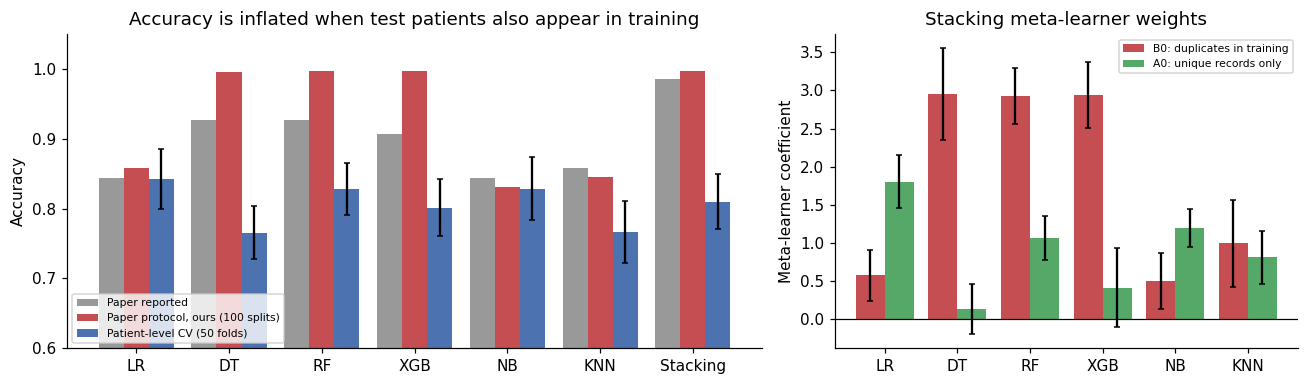

Mean meta weights B0: {'LR': np.float64(0.58), 'DT': np.float64(2.95), 'RF': np.float64(2.93), 'XGB': np.float64(2.94), 'NB': np.float64(0.49), 'KNN': np.float64(0.99)}
Mean meta weights A0: {'LR': np.float64(1.8), 'DT': np.float64(0.13), 'RF': np.float64(1.06), 'XGB': np.float64(0.41), 'NB': np.float64(1.19), 'KNN': np.float64(0.81)}


In [25]:
# Optimism gap: paper protocol (100 record-level splits) versus patient-level CV
leaky_acc = sweep.groupby('Model')['Accuracy'].mean().loc[ALL_MODELS]
fair = fold_paper.groupby('Method')['Accuracy']
fair_acc = pd.Series({m: fair.mean()[f'{m} (paper)'] for m in MODEL_ORDER} | {'Stacking': fair.mean()['B0']})
fair_sd = pd.Series({m: fair.std()[f'{m} (paper)'] for m in MODEL_ORDER} | {'Stacking': fair.std()['B0']})
gap = pd.DataFrame({'Paper reported': PAPER_T11['Accuracy'], 'Paper protocol (100 splits)': leaky_acc.round(4),
                    'Patient-level CV': fair_acc.round(4), 'Optimism (pp)': ((leaky_acc - fair_acc) * 100).round(1)})
gap.to_csv(RES_DIR / 'optimism_gap.csv')
print(gap.to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6), gridspec_kw={'width_ratios': [1.5, 1]})
x = np.arange(len(ALL_MODELS)); w = 0.27
ax = axes[0]
ax.bar(x - w, gap['Paper reported'], w, label='Paper reported', color='#999999')
ax.bar(x, gap['Paper protocol (100 splits)'], w, label='Paper protocol, ours (100 splits)', color='#C44E52')
ax.bar(x + w, fair_acc, w, yerr=fair_sd, capsize=2, label='Patient-level CV (50 folds)', color='#4C72B0')
ax.set_xticks(x, ALL_MODELS); ax.set_ylim(0.6, 1.05); ax.set_ylabel('Accuracy')
ax.set_title('Accuracy is inflated when test patients also appear in training'); ax.legend(fontsize=7, loc='lower left')
ax = axes[1]
wb, wa = np.array(weights['w_B0'].tolist()), np.array(weights['w_A0'].tolist())
ax.bar(x[:6] - 0.2, wb.mean(0), 0.4, yerr=wb.std(0), capsize=2, color='#C44E52', label='B0: duplicates in training')
ax.bar(x[:6] + 0.2, wa.mean(0), 0.4, yerr=wa.std(0), capsize=2, color='#55A868', label='A0: unique records only')
ax.axhline(0, c='k', lw=0.8); ax.set_xticks(x[:6], MODEL_ORDER); ax.set_ylabel('Meta-learner coefficient')
ax.set_title('Stacking meta-learner weights'); ax.legend(fontsize=7)
plt.tight_layout(); plt.savefig(FIG_DIR / 'fig_optimism_and_weights.png', bbox_inches='tight'); plt.show()
pd.DataFrame({'B0 mean': wb.mean(0), 'B0 std': wb.std(0), 'A0 mean': wa.mean(0), 'A0 std': wa.std(0)},
             index=MODEL_ORDER).round(3).to_csv(RES_DIR / 'meta_weights.csv')
print('Mean meta weights B0:', dict(zip(MODEL_ORDER, wb.mean(0).round(2))))
print('Mean meta weights A0:', dict(zip(MODEL_ORDER, wa.mean(0).round(2))))

## 4. Part 2: Proposed solution, Leakage-Aware Diversity-Pruned Stacking (LA-DPS)

**Limitation addressed.** The paper's pipeline never separates patients: duplicate copies of a patient sit on both sides of the test split and on both sides of every internal stacking fold. The first inflates the reported scores; the second corrupts training, because the meta-learner learns to trust the base learners that memorise duplicates (Section 3.6).

**LA-DPS**, fitted on each outer training fold only:
1. **Duplicate-aware training.** Exact duplicate records are collapsed before any internal resampling, so out-of-fold predictions are genuinely out-of-sample.
2. **Typed preprocessing inside the pipeline.** Invalid codes become missing values; nominal attributes (`cp`, `restecg`, `slope`, `thal`) are one-hot encoded instead of being treated as ordered numbers; numeric attributes are median-imputed and standardised.
3. **Nested hyperparameter optimisation.** Each of the same six model families is tuned by an inner stratified 5-fold grid search (ROC AUC).
4. **Diversity-pruned ensemble selection.** Starting from an empty ensemble, the base learner that most improves the cross-validated log-loss of the logistic-regression meta-learner is added, one at a time, until no candidate improves it. Redundant members are pruned.

**Ablation.** A0 = paper pipeline with duplicate-aware training (component 1); A1 = A0 + typed preprocessing; A2 = A1 + nested HPO (all six members); **A3 = LA-DPS** (A2 + pruning). All methods share the same 50 patient-level outer folds, so comparisons are paired.

In [26]:
NOMINAL, BINARY = ['cp', 'restecg', 'slope', 'thal'], ['sex', 'fbs', 'exang']
NUMERIC = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']

def _flag_invalid(X):
    X = pd.DataFrame(X, columns=FEATURES).astype(float).copy()
    X.loc[X['ca'] == 4, 'ca'] = np.nan
    X.loc[X['thal'] == 0, 'thal'] = np.nan
    return X

def typed_preprocessor():
    ct = ColumnTransformer([
        ('nom', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                          ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), NOMINAL),
        ('bin', 'passthrough', BINARY),
        ('num', Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())]), NUMERIC)])
    return Pipeline([('flag', FunctionTransformer(_flag_invalid)), ('ct', ct)])

def tuned_base_models(seed=SEED):
    return {'LR': LogisticRegression(max_iter=2000),
            'DT': DecisionTreeClassifier(criterion='entropy', random_state=seed),
            'RF': RandomForestClassifier(n_estimators=100, random_state=seed, n_jobs=1),
            'XGB': XGBClassifier(learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
                                 random_state=seed, eval_metric='logloss', n_jobs=1),
            'NB': GaussianNB(),
            'KNN': KNeighborsClassifier()}

HPO_GRIDS = {'LR': {'C': [0.01, 0.1, 0.3, 1, 10]},
             'DT': {'max_depth': [2, 3, 4, 5, 6, None], 'min_samples_leaf': [1, 10]},
             'RF': {'max_features': ['sqrt', 0.5], 'min_samples_leaf': [1, 5]},
             'XGB': {'max_depth': [2, 3, 4], 'n_estimators': [100, 300]},
             'NB': {'var_smoothing': [1e-9, 1e-3, 1e-2, 1e-1]},
             'KNN': {'n_neighbors': [5, 9, 15, 21, 31], 'weights': ['uniform', 'distance']}}

class LADPS(BaseEstimator, ClassifierMixin):
    """Leakage-Aware, Diversity-Pruned Stacking. One fit yields two variants:
    'full' (all six members, used for ablation A1/A2) and 'pruned' (LA-DPS, A3)."""

    def __init__(self, base_models=None, grids=None, preprocessor=None, cv=5, tol=1e-4,
                 seed=SEED, tune=True, dedup=True, variant='pruned'):
        self.base_models, self.grids, self.preprocessor = base_models, grids, preprocessor
        self.cv, self.tol, self.seed = cv, tol, seed
        self.tune, self.dedup, self.variant = tune, dedup, variant

    def _meta_score(self, P, y):
        skf = StratifiedKFold(self.cv, shuffle=True, random_state=self.seed + 1)
        p = cross_val_predict(LogisticRegression(max_iter=1000), P, y, cv=skf, method='predict_proba')[:, 1]
        return -log_loss(y, p)

    def fit(self, X, y):
        X = pd.DataFrame(X, columns=FEATURES); y = np.asarray(y)
        if self.dedup:                                   # component 1: duplicate-aware training
            d = X.assign(_y=y).drop_duplicates()
            X, y = d[FEATURES], d['_y'].values
        skf = StratifiedKFold(self.cv, shuffle=True, random_state=self.seed)
        self.tuned_, self.best_params_ = {}, {}
        for name, est in self.base_models.items():      # components 2 and 3
            pipe = Pipeline([('prep', clone(self.preprocessor)), ('clf', clone(est))])
            if self.tune and self.grids:
                gs = GridSearchCV(pipe, {f'clf__{k}': v for k, v in self.grids[name].items()},
                                  scoring='roc_auc', cv=skf, n_jobs=1).fit(X, y)
                pipe = gs.best_estimator_
                self.best_params_[name] = {k[5:]: v for k, v in gs.best_params_.items()}
            self.tuned_[name] = pipe
        self.names_ = list(self.tuned_)
        oof = np.column_stack([cross_val_predict(clone(self.tuned_[n]), X, y, cv=skf,
                                                 method='predict_proba')[:, 1] for n in self.names_])
        self.oof_corr_ = np.corrcoef(oof.T)
        selected, best, remaining, self.path_ = [], -np.inf, list(range(len(self.names_))), []
        while remaining:                                 # component 4: greedy forward selection
            scores = {j: self._meta_score(oof[:, selected + [j]], y) for j in remaining}
            j = max(scores, key=scores.get)
            if scores[j] <= best + self.tol:
                break
            selected.append(j); remaining.remove(j); best = scores[j]
            self.path_.append((self.names_[j], round(-best, 4)))
        self.selected_ = [self.names_[j] for j in selected]
        self.fitted_ = {n: clone(self.tuned_[n]).fit(X, y) for n in self.names_}
        self.meta_full_ = LogisticRegression(max_iter=1000).fit(oof, y)
        self.meta_pruned_ = LogisticRegression(max_iter=1000).fit(oof[:, selected], y)
        self.classes_ = np.array([0, 1])
        return self

    def base_proba(self, X):
        X = pd.DataFrame(X, columns=FEATURES)
        return pd.DataFrame({n: self.fitted_[n].predict_proba(X)[:, 1] for n in self.names_})

    def predict_proba(self, X, variant=None):
        P = self.base_proba(X)
        if (variant or self.variant) == 'pruned':
            return self.meta_pruned_.predict_proba(P[self.selected_].values)
        return self.meta_full_.predict_proba(P[self.names_].values)

    def predict(self, X, variant=None):
        return (self.predict_proba(X, variant)[:, 1] >= 0.5).astype(int)

print('LA-DPS defined.')

LA-DPS defined.


In [27]:
def run_fold_proposed(fold):
    r, k, tr, te = fold
    Xtr, ytr, Xte, yte = X_raw.iloc[tr], y_all[tr], X_raw.iloc[te], y_all[te]
    out = []
    a1 = LADPS(paper_base_models(), None, typed_preprocessor(), tune=False).fit(Xtr, ytr)
    prob = a1.predict_proba(Xte, 'full')[:, 1]
    out.append({'rep': r, 'fold': k, 'Method': 'A1', **evaluate(yte, (prob >= 0.5).astype(int), prob)})
    m = LADPS(tuned_base_models(), HPO_GRIDS, typed_preprocessor(), tune=True).fit(Xtr, ytr)
    for variant, label in [('full', 'A2'), ('pruned', 'A3 (LA-DPS)')]:
        prob = m.predict_proba(Xte, variant)[:, 1]
        out.append({'rep': r, 'fold': k, 'Method': label, **evaluate(yte, (prob >= 0.5).astype(int), prob)})
    P = m.base_proba(Xte)
    for name in MODEL_ORDER:
        out.append({'rep': r, 'fold': k, 'Method': f'{name} (tuned)',
                    **evaluate(yte, (P[name] >= 0.5).astype(int), P[name])})
    info = {'rep': r, 'fold': k, 'selected': m.selected_, 'path': m.path_,
            'best_params': m.best_params_, 'oof_corr': m.oof_corr_.tolist()}
    return out, info

t0 = time.time()
res_prop = Parallel(n_jobs=N_JOBS)(delayed(cached_call)(f'prop_{f[0]}_{f[1]}', run_fold_proposed, f)
                                   for f in GROUP_FOLDS)
fold_prop = pd.DataFrame([r for out, _ in res_prop for r in out])
sel_info = [i for _, i in res_prop]
folds_all = pd.concat([fold_paper, fold_prop], ignore_index=True)
folds_all.to_csv(RES_DIR / 'part2_foldwise.csv', index=False)
with open(RES_DIR / 'part2_selection_info.json', 'w') as f:
    json.dump(sel_info, f, default=str)
print(f'({time.time() - t0:.0f}s)')

(715s)


### 4.1 Results: ablation and comparison with the paper's pipeline (patient-level CV, 50 folds)

In [28]:
MAIN = ['B0', 'A0', 'A1', 'A2', 'A3 (LA-DPS)']
REF = [f'{m} (paper)' for m in MODEL_ORDER] + [f'{m} (tuned)' for m in MODEL_ORDER]
ga = folds_all.groupby('Method')
part2_mean, part2_std = ga[METRICS].mean(), ga[METRICS].std()
part2_tab = (part2_mean.map('{:.4f}'.format) + ' ± ' + part2_std.map('{:.4f}'.format)).loc[MAIN + REF]
part2_tab.to_csv(RES_DIR / 'part2_summary.csv')
part2_mean.loc[MAIN + REF].round(4).to_csv(RES_DIR / 'part2_means.csv')
part2_tab.loc[MAIN]

,Accuracy,Precision,Recall,F1,AUC,Specificity,MCC,Brier
Method,,,,,,,,
B0,0.8102 ± 0.0398,0.8130 ± 0.0501,0.8500 ± 0.0523,0.8294 ± 0.0351,0.8960 ± 0.0298,0.7628 ± 0.0768,0.6196 ± 0.0808,0.1600 ± 0.0330
A0,0.8410 ± 0.0400,0.8389 ± 0.0522,0.8812 ± 0.0555,0.8576 ± 0.0350,0.9148 ± 0.0325,0.7934 ± 0.0823,0.6832 ± 0.0804,0.1169 ± 0.0241
A1,0.8391 ± 0.0442,0.8354 ± 0.0557,0.8825 ± 0.0594,0.8562 ± 0.0385,0.9100 ± 0.0357,0.7878 ± 0.0845,0.6795 ± 0.0899,0.1177 ± 0.0253
A2,0.8437 ± 0.0428,0.8426 ± 0.0528,0.8812 ± 0.0633,0.8593 ± 0.0388,0.9146 ± 0.0346,0.7993 ± 0.0789,0.6889 ± 0.0869,0.1156 ± 0.0251
A3 (LA-DPS),0.8427 ± 0.0460,0.8409 ± 0.0546,0.8811 ± 0.0624,0.8586 ± 0.0413,0.9146 ± 0.0355,0.7971 ± 0.0803,0.6865 ± 0.0936,0.1165 ± 0.0253


In [29]:
def paired(a, b, metric):
    A = folds_all[folds_all.Method == a].sort_values(['rep', 'fold'])[metric].values
    B = folds_all[folds_all.Method == b].sort_values(['rep', 'fold'])[metric].values
    d = A - B
    n_test = np.mean([len(te) for *_, te in GROUP_FOLDS]); n_train = len(uniq) - n_test
    var = np.var(d, ddof=1)
    t = d.mean() / np.sqrt((1 / len(d) + n_test / n_train) * var) if var > 0 else np.nan
    p_t = 2 * stats.t.sf(abs(t), df=len(d) - 1) if var > 0 else np.nan
    p_w = stats.wilcoxon(A, B).pvalue if np.any(d != 0) else 1.0
    better = d < 0 if metric == 'Brier' else d > 0
    worse = d > 0 if metric == 'Brier' else d < 0
    return {'Comparison': f'{a} vs {b}', 'Metric': metric, 'Mean diff': round(d.mean(), 4),
            'Corrected t': round(t, 2), 'p (corrected t)': round(p_t, 4), 'p (Wilcoxon)': round(p_w, 4),
            'Wins/Ties/Losses': f'{better.sum()}/{(d == 0).sum()}/{worse.sum()}'}

pairs = [('A0', 'B0'), ('A1', 'A0'), ('A2', 'A1'), ('A3 (LA-DPS)', 'A2'),
         ('A3 (LA-DPS)', 'A0'), ('A3 (LA-DPS)', 'B0')]
tests = pd.DataFrame([paired(a, b, m) for a, b in pairs for m in ['Accuracy', 'F1', 'AUC', 'MCC', 'Brier']])
tests.to_csv(RES_DIR / 'part2_stat_tests.csv', index=False)
print('Nadeau and Bengio corrected resampled t-test (paired over 50 patient-level folds) and '
      'Wilcoxon signed-rank test. Brier: lower is better.')
tests

Nadeau and Bengio corrected resampled t-test (paired over 50 patient-level folds) and Wilcoxon signed-rank test. Brier: lower is better.


,Comparison,Metric,Mean diff,Corrected t,p (corrected t),p (Wilcoxon),Wins/Ties/Losses
0,A0 vs B0,Accuracy,0.0308,1.74,0.0886,0.0000,39/4/7
1,A0 vs B0,F1,0.0281,1.68,0.1002,0.0000,40/1/9
2,A0 vs B0,AUC,0.0187,1.96,0.0554,0.0000,42/1/7
3,A0 vs B0,MCC,0.0636,1.76,0.0841,0.0000,42/1/7
4,A0 vs B0,Brier,-0.0431,-3.48,0.0011,0.0000,49/0/1
5,A1 vs A0,Accuracy,-0.0019,-0.11,0.9123,0.7937,20/12/18
6,A1 vs A0,F1,-0.0014,-0.08,0.9327,0.8515,22/7/21
7,A1 vs A0,AUC,-0.0048,-0.59,0.5611,0.0450,16/1/33
8,A1 vs A0,MCC,-0.0036,-0.10,0.9198,0.8705,20/7/23
9,A1 vs A0,Brier,0.0008,0.12,0.9033,0.9847,28/0/22


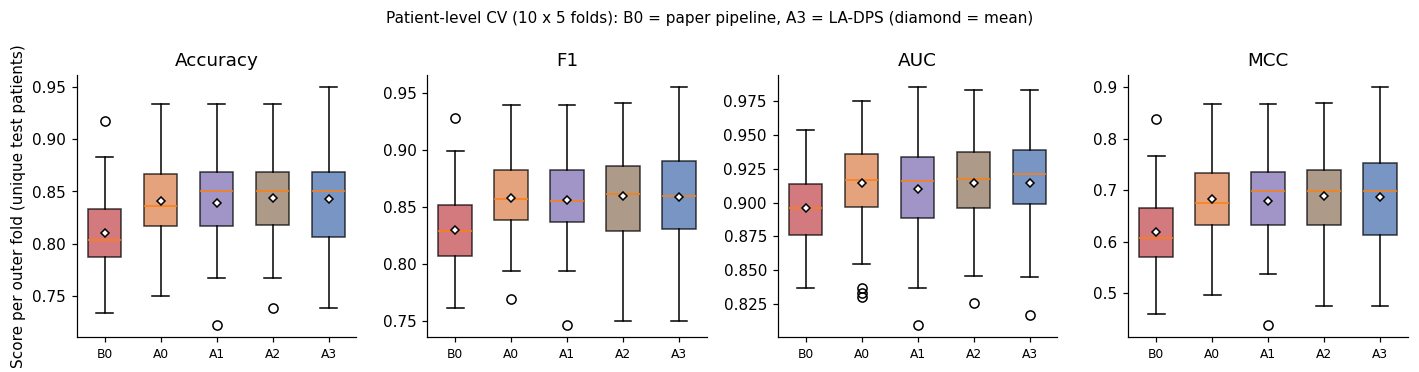

In [30]:
fig, axes = plt.subplots(1, 4, figsize=(13, 3.4))
cols = ['#C44E52', '#DD8452', '#8172B3', '#937860', '#4C72B0']
for ax, metric in zip(axes, ['Accuracy', 'F1', 'AUC', 'MCC']):
    data = [folds_all[folds_all.Method == m][metric].values for m in MAIN]
    bp = ax.boxplot(data, patch_artist=True, widths=0.6, showmeans=True,
                    meanprops={'marker': 'D', 'markerfacecolor': 'white', 'markeredgecolor': 'k', 'markersize': 4})
    for patch, c in zip(bp['boxes'], cols):
        patch.set_facecolor(c); patch.set_alpha(0.75)
    ax.set_xticks(range(1, 6), ['B0', 'A0', 'A1', 'A2', 'A3'], fontsize=8); ax.set_title(metric)
axes[0].set_ylabel('Score per outer fold (unique test patients)')
plt.suptitle('Patient-level CV (10 x 5 folds): B0 = paper pipeline, A3 = LA-DPS (diamond = mean)', fontsize=10)
plt.tight_layout(); plt.savefig(FIG_DIR / 'fig_part2_boxplots.png', bbox_inches='tight'); plt.show()

Ensemble size: mean 3.58, distribution {2: 4, 3: 20, 4: 20, 5: 5, 6: 1}
     Selected in % of folds  Chosen first (folds)                       Most frequent tuned params
LR                     96.0                    42                                       {"C": 0.3}
DT                     32.0                     0         {"max_depth": 5, "min_samples_leaf": 10}
RF                     94.0                     0  {"max_features": "sqrt", "min_samples_leaf": 5}
XGB                    54.0                     3            {"max_depth": 2, "n_estimators": 100}
NB                     62.0                     4                           {"var_smoothing": 0.1}
KNN                    20.0                     1       {"n_neighbors": 21, "weights": "distance"}


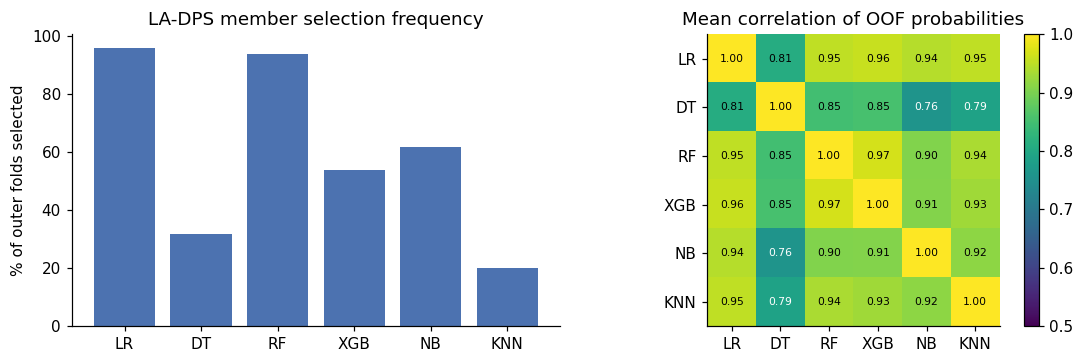

In [31]:
sel_freq = pd.Series([n for i in sel_info for n in i['selected']]).value_counts().reindex(MODEL_ORDER, fill_value=0)
sizes = pd.Series([len(i['selected']) for i in sel_info])
first = pd.Series([i['selected'][0] for i in sel_info]).value_counts()
corr = np.mean([np.array(i['oof_corr']) for i in sel_info], axis=0)
params = pd.DataFrame([{'Model': n, 'Params': json.dumps(i['best_params'][n], default=str)}
                       for i in sel_info for n in MODEL_ORDER])
top_params = params.groupby('Model')['Params'].agg(lambda s: s.value_counts().index[0]).loc[MODEL_ORDER]
selection = pd.DataFrame({'Selected in % of folds': (sel_freq / len(sel_info) * 100).round(0),
                          'Chosen first (folds)': first.reindex(MODEL_ORDER, fill_value=0),
                          'Most frequent tuned params': top_params})
selection.to_csv(RES_DIR / 'part2_selection_frequency.csv')
print(f'Ensemble size: mean {sizes.mean():.2f}, distribution {sizes.value_counts().sort_index().to_dict()}')
print(selection.to_string())

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
axes[0].bar(MODEL_ORDER, sel_freq / len(sel_info) * 100, color='#4C72B0')
axes[0].set_ylabel('% of outer folds selected'); axes[0].set_title('LA-DPS member selection frequency')
im = axes[1].imshow(corr, cmap='viridis', vmin=0.5, vmax=1)
for (i, j), v in np.ndenumerate(corr):
    axes[1].text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=7, color='white' if v < 0.8 else 'black')
axes[1].set_xticks(range(6), MODEL_ORDER); axes[1].set_yticks(range(6), MODEL_ORDER)
axes[1].set_title('Mean correlation of OOF probabilities'); plt.colorbar(im, ax=axes[1], fraction=0.046)
plt.tight_layout(); plt.savefig(FIG_DIR / 'fig_selection.png', bbox_inches='tight'); plt.show()

### 4.2 Comparative summary: paper, reproduction and proposed solution

In [32]:
def row(label, protocol, src):
    return {'Result': label, 'Protocol': protocol, **{c: round(float(src[c]), 4) for c in
            ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']}}

sw_mean = sweep.groupby('Model')[['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']].mean()
summary = pd.DataFrame([
    row('Paper, stacking (reported)', 'Single record-level split', PAPER_T11.loc['Stacking']),
    row('Reproduction, stacking', f'Recovered split (seed {SPLIT_SEED})', repro.loc['Stacking']),
    row('Reproduction, stacking', f'Mean of {N_RANDOM_SPLITS} record-level splits', sw_mean.loc['Stacking']),
    row('Paper pipeline B0, stacking', 'Patient-level CV, 50 folds', part2_mean.loc['B0']),
    row('Best single paper model (patient-level)', 'Patient-level CV, 50 folds',
        part2_mean.loc[[f'{m} (paper)' for m in MODEL_ORDER]].sort_values('AUC').iloc[-1]),
    row('Proposed LA-DPS (A3)', 'Patient-level CV, 50 folds', part2_mean.loc['A3 (LA-DPS)'])])
summary.to_csv(RES_DIR / 'summary_comparison.csv', index=False)
print(f'Total runtime: {(time.time() - T_START) / 60:.1f} min')
summary

Total runtime: 19.3 min


,Result,Protocol,Accuracy,Precision,Recall,F1,AUC
0,"Paper, stacking (reported)",Single record-level split,0.9853,1.0000,0.9727,0.9861,0.9880
1,"Reproduction, stacking",Recovered split (seed 2258),1.0000,1.0000,1.0000,1.0000,1.0000
2,"Reproduction, stacking",Mean of 100 record-level splits,0.9972,0.9972,0.9974,0.9973,0.9998
3,"Paper pipeline B0, stacking","Patient-level CV, 50 folds",0.8102,0.8130,0.8500,0.8294,0.8960
4,Best single paper model (patient-level),"Patient-level CV, 50 folds",0.8426,0.8429,0.8774,0.8579,0.9135
5,Proposed LA-DPS (A3),"Patient-level CV, 50 folds",0.8427,0.8409,0.8811,0.8586,0.9146
